# Bottlegrowth High-r Production: Demography & DFE Inference Results

In [ ]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats.distributions as ssd

BASE_DIR = "/Users/srgib/GitHub/dadi_polyploidy/thesis_figures/SLiM_DFE_results/Bottlegrowth"
DEMOG_DIR = os.path.join(BASE_DIR, "demography")
DFE_DIR = os.path.join(BASE_DIR, "DFE")

REP_RE = re.compile(r'REP_(\d+)')

TRUE_SHAPE = 0.27
TRUE_SCALE = 129.3952

method_colors = {
    'dadi_nomisid': "#1f77b4",
    'dadi_misid': "#ff7f0e",
    'fastdfe_nomisid': "#2ca02c",
    'fastdfe_misid': "#d62728",
}
method_labels = {
    'dadi_nomisid': 'dadi (no misid)',
    'dadi_misid': 'dadi (misid)',
    'fastdfe_nomisid': 'fastDFE (no misid)',
    'fastdfe_misid': 'fastDFE (misid)',
}


def get_best_fit_params(opt_file):
    """
    Load the best-fit row (highest log-likelihood < 0) from a dadi
    optimization results file, keyed by that file's own header. Works for
    both demography and DFE optimization files, with or without a misid
    column, since the parameter names are read from the header rather
    than passed in.
    """
    with open(opt_file, 'r') as f:
        lines = f.readlines()
    param_names = lines[0].strip().split('\t')[1:]

    best_line, best_ll = None, float('-inf')
    for line in lines[1:]:
        parts = line.strip().split('\t')
        ll = float(parts[0])
        if (ll > best_ll) and (ll < 0):
            best_ll = ll
            best_line = parts

    return {name: float(best_line[i + 1]) for i, name in enumerate(param_names)}


def parse_fastdfe_file(fd_file):
    """Load the single optimized-parameter row from a fast_DFE_optimization file."""
    with open(fd_file, 'r') as f:
        header = f.readline().strip().split('\t')
        values = f.readline().strip().split('\t')
    return {name: float(v) for name, v in zip(header, values)}


def load_replicates(directory, file_prefix, parser):
    """Map REP number -> parsed parameter dict for every matching file in `directory`."""
    results = {}
    for path in glob.glob(os.path.join(directory, f"{file_prefix}*.txt")):
        rep = int(REP_RE.search(os.path.basename(path)).group(1))
        results[rep] = parser(path)
    return results


## Demographic parameter estimates

In [2]:
# six demographic inference configurations: {small, med, large} x {misid, no misid}
demog_configs = {
    'small': 'bg_small',
    'med': 'bg_med',
    'large': 'bg_large',
    'small_misid': 'bg_misid_small',
    'med_misid': 'bg_misid_med',
    'large_misid': 'bg_misid_large',
}

demog_data = {
    label: load_replicates(os.path.join(DEMOG_DIR, folder), 'optimization_', get_best_fit_params)
    for label, folder in demog_configs.items()
}


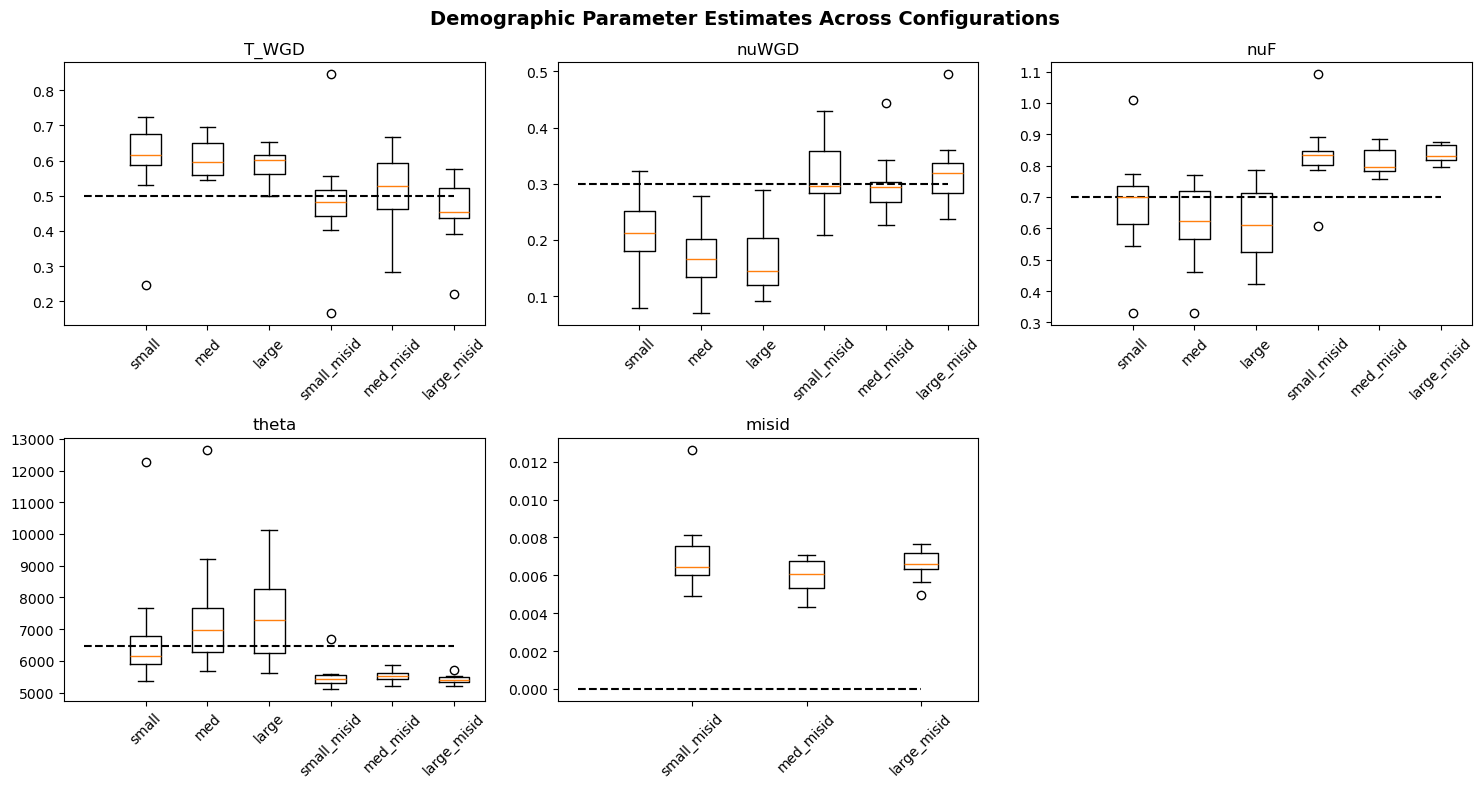

In [4]:
# T_WGD, nuWGD, nuF, and theta are estimated in all six configs; misid only in the three *_misid configs
demog_params = ['T_WGD', 'nuWGD', 'nuF', 'theta', 'misid']
true_vals = [.5, .3, .7, 6470, 0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, param, true_val in zip(axes, demog_params, true_vals):
    labels = [label for label, reps in demog_data.items() if param in next(iter(reps.values()))]
    values = [[rep_params[param] for rep_params in demog_data[label].values()] for label in labels]
    ax.boxplot(values, tick_labels=labels)
    ax.set_title(param)
    ax.tick_params(axis='x', rotation=45)
    ax.hlines(true_val, xmin=0, xmax=len(labels), color='black', linestyle='dashed')

axes[-1].axis('off')
fig.suptitle('Demographic Parameter Estimates Across Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'demography_boxplots.pdf'), bbox_inches='tight')
plt.show()


## DFE inference: shape & scale

In [3]:
# for each size, the no-misid and misid runs live in separate folders;
# each folder holds both the dadi (DFE_optimization_*) and fastDFE (fast_DFE_optimization_*) results
dfe_dirs = {
    'small': {'nomisid': 'bg_small', 'misid': 'bg_small_misid'},
    'med':   {'nomisid': 'bg_med',   'misid': 'bg_med_misid'},
    'large': {'nomisid': 'bg_large', 'misid': 'bg_large_misid'},
}

# dfe_shape_scale[size][method] -> list of (shape, scale) pairs over the 10 replicates
dfe_shape_scale = {}
for size, dirs in dfe_dirs.items():
    entry = {}
    for tag, folder in dirs.items():
        d = os.path.join(DFE_DIR, folder)
        dadi_reps = load_replicates(d, 'DFE_optimization_', get_best_fit_params)
        fd_reps = load_replicates(d, 'fast_DFE_optimization_', parse_fastdfe_file)

        # dadi's gamma DFE is already parameterized as shape (mu) / scale (sigma)
        entry[f'dadi_{tag}'] = [(p['mu'], p['sigma']) for p in dadi_reps.values()]
        # fastDFE parameterizes the deleterious DFE by mean S_d (negative, in 4*Ne*s units) and shape b;
        # converting to a dadi-style gamma scale: |S_d| / (2 * shape), where the factor of 2 accounts
        # for dadi and fastDFE scaling selection coefficients differently (2*Ne*s vs 4*Ne*s)
        entry[f'fastdfe_{tag}'] = [(p['b'], abs(p['S_d']) / (2*p['b'])) for p in fd_reps.values()]
    dfe_shape_scale[size] = entry

dfe_methods = ['dadi_nomisid', 'dadi_misid', 'fastdfe_nomisid', 'fastdfe_misid']


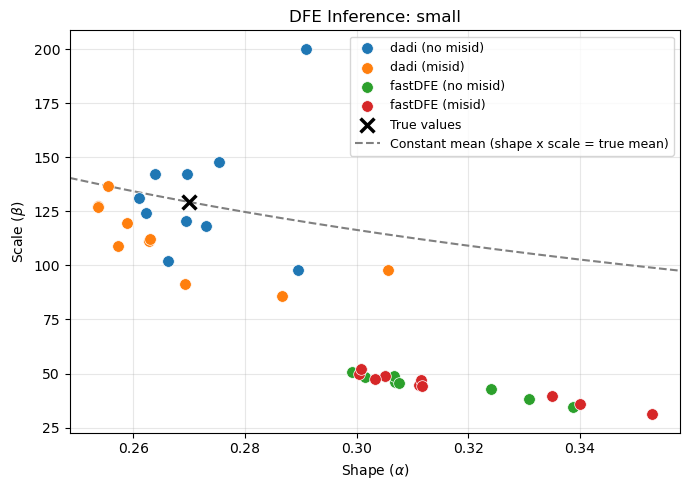

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for method in dfe_methods:
    shapes, scales = zip(*dfe_shape_scale['small'][method])
    ax.scatter(shapes, scales, label=method_labels[method], color=method_colors[method],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_SHAPE, TRUE_SCALE, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: shape * scale = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = TRUE_SHAPE * TRUE_SCALE
shape_range = np.linspace(*xlim, 200)
ax.plot(shape_range, true_mean / shape_range, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='Constant mean (shape x scale = true mean)')
ax.set_xlim(xlim)

ax.set_xlabel(r'Shape ($\alpha$)')
ax.set_ylabel(r'Scale ($\beta$)')
ax.set_title('DFE Inference: small')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_small.pdf'), bbox_inches='tight')
plt.show()


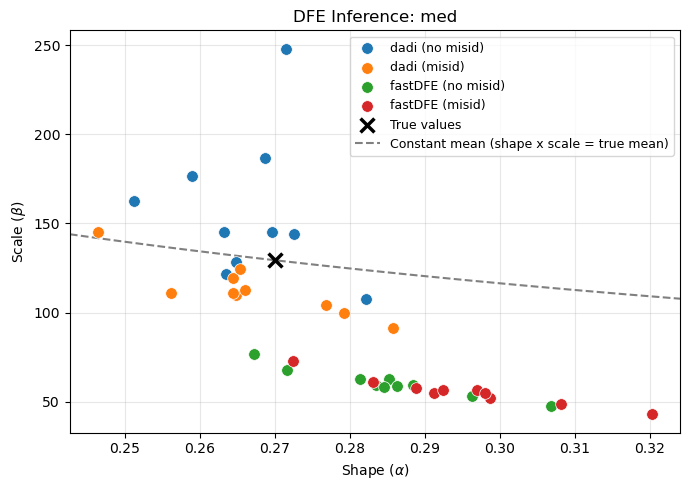

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for method in dfe_methods:
    shapes, scales = zip(*dfe_shape_scale['med'][method])
    ax.scatter(shapes, scales, label=method_labels[method], color=method_colors[method],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_SHAPE, TRUE_SCALE, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: shape * scale = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = TRUE_SHAPE * TRUE_SCALE
shape_range = np.linspace(*xlim, 200)
ax.plot(shape_range, true_mean / shape_range, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='Constant mean (shape x scale = true mean)')
ax.set_xlim(xlim)

ax.set_xlabel(r'Shape ($\alpha$)')
ax.set_ylabel(r'Scale ($\beta$)')
ax.set_title('DFE Inference: med')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_med.pdf'), bbox_inches='tight')
plt.show()


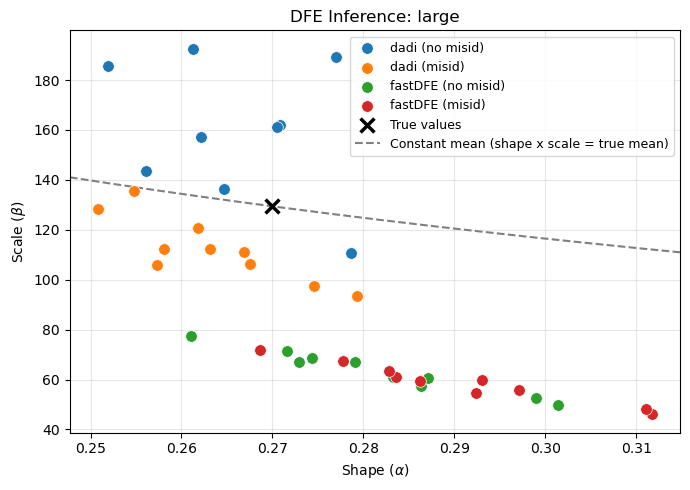

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for method in dfe_methods:
    shapes, scales = zip(*dfe_shape_scale['large'][method])
    ax.scatter(shapes, scales, label=method_labels[method], color=method_colors[method],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_SHAPE, TRUE_SCALE, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: shape * scale = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = TRUE_SHAPE * TRUE_SCALE
shape_range = np.linspace(*xlim, 200)
ax.plot(shape_range, true_mean / shape_range, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='Constant mean (shape x scale = true mean)')
ax.set_xlim(xlim)

ax.set_xlabel(r'Shape ($\alpha$)')
ax.set_ylabel(r'Scale ($\beta$)')
ax.set_title('DFE Inference: large')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_large.pdf'), bbox_inches='tight')
plt.show()


## Discretized DFE

In [7]:
bin_labels = ("gamma<1", "1<gamma<10", "10<gamma<100", "gamma>100")
group_colors = {'true': '#000000', **method_colors}
group_labels = {'true': 'True gamma', **method_labels}


def discretized_bins(shape, scale):
    """Proportion of a gamma(shape, scale) distribution falling in each of the four 2Ns bins."""
    c1 = ssd.gamma.cdf(1, shape, scale=scale)
    c10 = ssd.gamma.cdf(10, shape, scale=scale)
    c100 = ssd.gamma.cdf(100, shape, scale=scale)
    return [c1, c10 - c1, c100 - c10, 1 - c100]


def average_bins(shape_scale_pairs):
    """
    Average the discretized bins across replicates rather than averaging
    shape/scale first, since the mean of several gamma distributions'
    parameters does not itself define a gamma distribution.
    """
    bins = np.array([discretized_bins(shape, scale) for shape, scale in shape_scale_pairs])
    return bins.mean(axis=0)


true_bins = discretized_bins(TRUE_SHAPE, TRUE_SCALE)


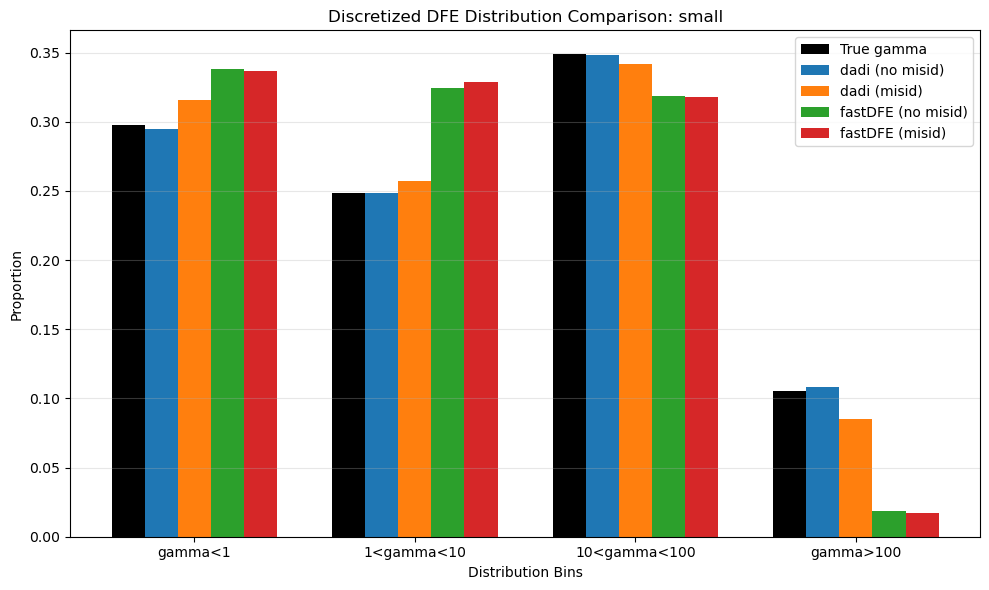

In [8]:
groups = ['true'] + dfe_methods
bin_vals = {'true': true_bins}
for method in dfe_methods:
    bin_vals[method] = average_bins(dfe_shape_scale['small'][method])

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=group_labels[group], color=group_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison: small')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_small.pdf'), bbox_inches='tight')
plt.show()


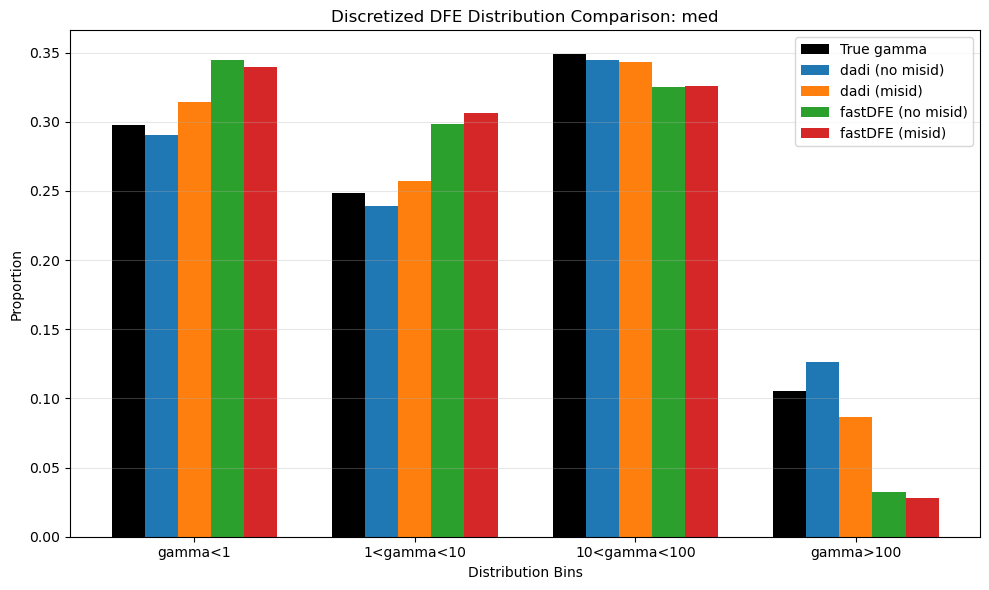

In [9]:
groups = ['true'] + dfe_methods
bin_vals = {'true': true_bins}
for method in dfe_methods:
    bin_vals[method] = average_bins(dfe_shape_scale['med'][method])

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=group_labels[group], color=group_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison: med')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_med.pdf'), bbox_inches='tight')
plt.show()


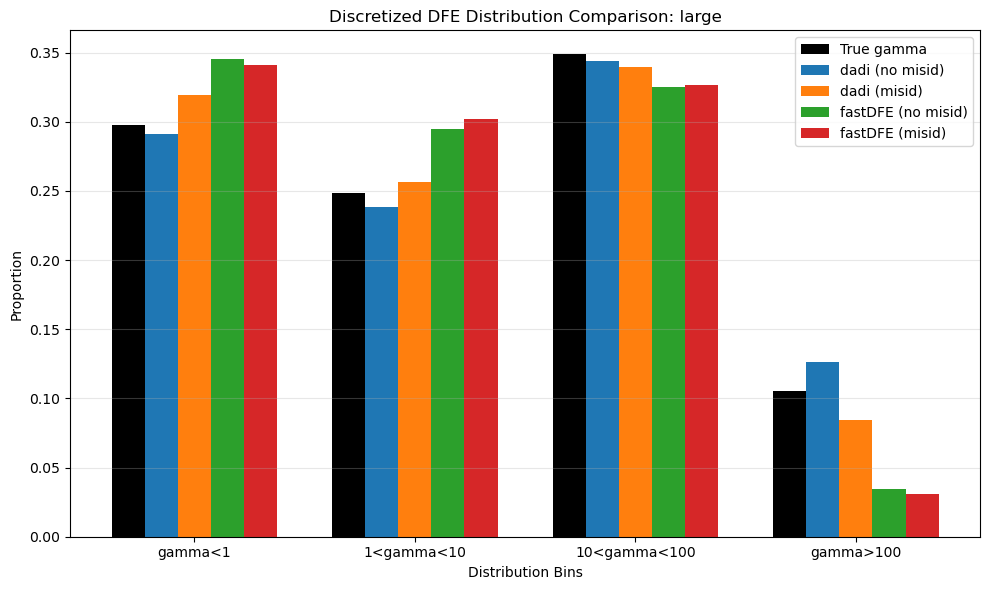

In [10]:
groups = ['true'] + dfe_methods
bin_vals = {'true': true_bins}
for method in dfe_methods:
    bin_vals[method] = average_bins(dfe_shape_scale['large'][method])

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=group_labels[group], color=group_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison: large')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_large.pdf'), bbox_inches='tight')
plt.show()
